<a href="https://colab.research.google.com/github/Zeldano118/QPon_NLP_PBA/blob/main/assignments/week%203/3_week3_bow_regex.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 3: Bag of Words + Regex — QPon Reviews
Re-run of BoW notebook, applied to 50 QPon reviews (25 positive + 25 negative).
Plus regex analysis for positive/negative insight patterns.

**Input:** `df_qpon_rev.csv`

In [ ]:
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('wordnet', quiet=True)

import pandas as pd
import re
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt
import seaborn as sns

---
## 1. Load & Sample Data

In [ ]:
from google.colab import files
uploaded = files.upload()

import io
for fn in uploaded.keys():
    df_full = pd.read_csv(io.BytesIO(uploaded[fn]))
    print(f'Loaded: {len(df_full):,} rows')

Saving df_qpon_rev.csv to df_qpon_rev.csv
Loaded: 4,684 rows


In [ ]:
# label sentiment
df_full['sentiment'] = df_full['score'].apply(
    lambda x: 'positive' if x >= 4 else ('negative' if x <= 2 else 'neutral')
)

# sample 25 positive + 25 negative
pos = df_full[df_full['sentiment'] == 'positive'].sample(25, random_state=42)
neg = df_full[df_full['sentiment'] == 'negative'].sample(25, random_state=42)
df = pd.concat([pos, neg]).reset_index(drop=True)

print(f'Sampled {len(df)} reviews: {len(pos)} positive + {len(neg)} negative')
df[['content', 'score', 'sentiment']].head()

Sampled 50 reviews: 25 positive + 25 negative


,content,score,sentiment
0,recommended,5,positive
1,aplikasi yg membantu dan menghemat,5,positive
2,Qpon adalah applikasi yang menjual voucher yan...,5,positive
3,sering** diskon y,5,positive
4,"Terima kasih QPON, kehadiran kalian membuat sa...",5,positive


---
## 2. BoW — Step 1: Tokenize, Remove Stopwords, Lemmatize
Following the 3-step BoW process from dosen's notebook.

In [ ]:
lemmatizer = WordNetLemmatizer()
stop_id = set(stopwords.words('indonesian'))

corpus = []
for text in df['content'].astype(str):
    sent = re.sub('[^a-zA-Z]', ' ', text)
    sent = sent.lower().split()
    sent = [lemmatizer.lemmatize(w) for w in sent if w not in stop_id and len(w) > 2]
    corpus.append(' '.join(sent))

print(f'{len(corpus)} documents processed')
print('Sample:', corpus[:3])

50 documents processed
Sample: ['recommended', 'aplikasi membantu menghemat', 'qpon applikasi menjual voucher murah cocok karyawan hemat jajan makan enak mantap qpon']


---
## 3. BoW — Step 2: Unique Words

In [ ]:
all_words = []
for sentence in corpus:
    for word in sentence.split():
        all_words.append(word)

unique_words = list(set(all_words))
print(f'Total words: {len(all_words)}')
print(f'Unique words: {len(unique_words)}')
print('Sample unique:', unique_words[:15])

Total words: 482
Unique words: 287
Sample unique: ['pergi', 'diskonnya', 'fitur', 'mendang', 'akun', 'solusinya', 'hut', 'saku', 'kecewa', 'yaudah', 'prose', 'solusi', 'kupon', 'bagus', 'pake']


---
## 4. BoW — Step 3: Word Frequency & Vectorization

In [ ]:
word_freq = Counter(all_words)
sorted_words = sorted(word_freq.items(), key=lambda x: x[1], reverse=True)

# word-to-number mapping
word_to_num = {w: i+1 for i, (w, _) in enumerate(sorted_words)}

print('Top 15 words:')
for w, c in sorted_words[:15]:
    print(f'  {w:20s} {c:>4}')

Top 15 words:
  aplikasi               14
  hemat                  13
  qpon                   10
  nya                    10
  diskon                  8
  promo                   7
  gak                     7
  aja                     7
  voucher                 6
  makan                   6
  anak                    6
  banget                  6
  murah                   5
  tukar                   5
  beli                    5


In [ ]:
# CountVectorizer
cv = CountVectorizer()
bow_matrix = cv.fit_transform(corpus).toarray()

print(f'BoW matrix: {bow_matrix.shape[0]} docs x {bow_matrix.shape[1]} features')

bow_df = pd.DataFrame(bow_matrix, columns=cv.get_feature_names_out())
bow_df.head()

BoW matrix: 50 docs x 287 features


,abis,acc,admin,aja,ajg,ajh,akhirat,akuin,akun,alasan,...,vocer,voucher,vouchernya,wajib,wanasari,wkwkwk,wkwwkk,worth,yaaa,yaudah
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


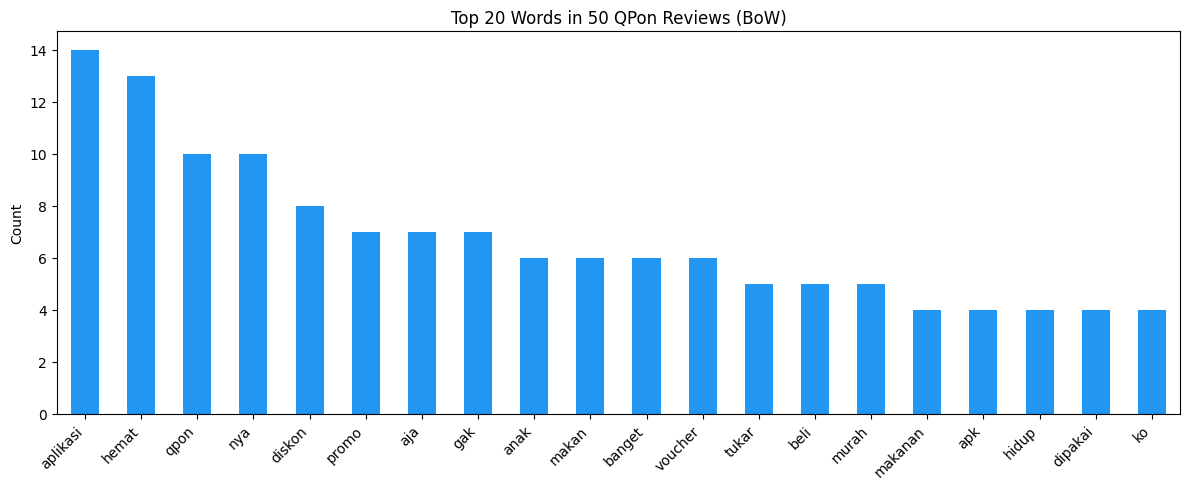

In [ ]:
# top words bar chart
term_freq = bow_df.sum().sort_values(ascending=False).head(20)

plt.figure(figsize=(12, 5))
term_freq.plot.bar(color='#2196F3')
plt.title('Top 20 Words in 50 QPon Reviews (BoW)')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

---
## 5. Regex Analysis — Positive & Negative Insights

In [ ]:
raw = df_full['content'].astype(str)

# negative patterns
neg_patterns = {
    'error/crash': r'error|crash|bug|force close',
    'gagal/tidak bisa': r'gagal|tidak bisa|gabisa|gbisa|gak bisa|tdk bisa',
    'lambat/lemot': r'lambat|lemot|lama|loading',
    'kecewa': r'kecewa|rugi|bohong|tipu|nipu',
}

# positive patterns
pos_patterns = {
    'promo/cashback': r'promo|cashback|diskon|voucher|kupon',
    'bagus/mantap': r'bagus|mantap|keren|top|oke|recommended',
    'mudah/gampang': r'mudah|gampang|simpel|praktis',
    'murah/hemat': r'murah|hemat|terjangkau|worth',
}

print('=== NEGATIVE PATTERNS ===')
for label, pattern in neg_patterns.items():
    count = raw.str.contains(pattern, case=False, na=False).sum()
    pct = count / len(raw) * 100
    print(f'  {label:20s}: {count:>5,} reviews ({pct:.1f}%)')

print()
print('=== POSITIVE PATTERNS ===')
for label, pattern in pos_patterns.items():
    count = raw.str.contains(pattern, case=False, na=False).sum()
    pct = count / len(raw) * 100
    print(f'  {label:20s}: {count:>5,} reviews ({pct:.1f}%)')

=== NEGATIVE PATTERNS ===
  error/crash         :    72 reviews (1.5%)
  gagal/tidak bisa    :   737 reviews (15.7%)
  lambat/lemot        :   271 reviews (5.8%)
  kecewa              :   348 reviews (7.4%)

=== POSITIVE PATTERNS ===
  promo/cashback      : 1,669 reviews (35.6%)
  bagus/mantap        :   698 reviews (14.9%)
  mudah/gampang       :   393 reviews (8.4%)
  murah/hemat         :   618 reviews (13.2%)


In [ ]:
# avg rating for reviews matching each pattern
print('Average rating per pattern:\n')
for label, pattern in {**neg_patterns, **pos_patterns}.items():
    mask = raw.str.contains(pattern, case=False, na=False)
    if mask.sum() > 0:
        avg = df_full.loc[mask, 'score'].mean()
        print(f'  {label:20s}: avg rating {avg:.2f} (n={mask.sum()})')

Average rating per pattern:

  error/crash         : avg rating 1.58 (n=72)
  gagal/tidak bisa    : avg rating 1.41 (n=737)
  lambat/lemot        : avg rating 2.15 (n=271)
  kecewa              : avg rating 1.38 (n=348)
  promo/cashback      : avg rating 3.34 (n=1669)
  bagus/mantap        : avg rating 4.51 (n=698)
  mudah/gampang       : avg rating 4.83 (n=393)
  murah/hemat         : avg rating 4.74 (n=618)


In [ ]:
# sample reviews matching negative patterns
print('=== SAMPLE NEGATIVE REVIEWS ===')
for label, pattern in neg_patterns.items():
    matches = df_full[raw.str.contains(pattern, case=False, na=False)]
    if len(matches) > 0:
        sample = matches.iloc[0]
        print(f'\n[{label}] Rating: {sample["score"]}')
        print(f'  {str(sample["content"])[:200]}')

=== SAMPLE NEGATIVE REVIEWS ===

[error/crash] Rating: 1
  aplikasi banyak error. perkara ganti hape dibilang gonta ganti akun, yang diganti padahal device nya bukan akunnya. ganti hape di bulan januari semenjak itu udah gabisa pake app, mulai bikin laporan d

[gagal/tidak bisa] Rating: 1
  tidak bisa login (alasan aktivitas mencurigakan). Jawaban CS terlalu template dan tidak ada solusi yang diberikan. sayang disayangkan, sudah banyak sekali di review ini maupun di web yang protes terka

[lambat/lemot] Rating: 1
  aplikasi ini UI nya aja bagus, backend API problem banget, b90 banget tu developer, redeem aja problematic dengan lokasi, halaman, dan perangkat user, sama itu cs wa gak guna gak bisa dijadikan solusi

[kecewa] Rating: 1
  QPON tidak profesional dalam membentuk tim kerja salah satunya sales, Saya sebagai pengusaha rumah makan mau berbagi pengalaman yg tidak menyenangkan suatu hari ada customer kami datang menunjukan Tak


---
## Summary

**BoW:** Applied the 3-step process (tokenize+stopwords+lemmatize → unique words → frequency + vectorization) on 50 QPon reviews (25 positive + 25 negative).

**Regex insights:** Pattern matching reveals which complaint types and praise types are most common in QPon reviews, with corresponding average ratings.